# Audio as an Optical Field: Fourier-Derived Images for Music Genre Classification

This notebook builds a complete computational optics-inspired pipeline from labeled audio to publishable figures and machine-learning results. The core idea is to treat short-time Fourier transform (STFT) coefficients as a complex field $E(t, f)$ over time and frequency, then simulate an optical measurement by forming the intensity of a propagated or transformed field.

## Research goals
1. Transform audio clips into visually meaningful, optics-inspired images using discrete Fourier analysis.
2. Train a genre classifier on those transformed images and compare multiple representations.
3. Optionally probe the trained model with non-audio images to see whether the resulting predictions are informative or merely arbitrary.

## Experimental framing
Given audio $x[n]$, we compute an STFT and interpret its complex coefficients as a field $E(t, f)$. A 2D Fourier transform of that field yields an intensity distribution $I = |athcal{F}E|^2$, analogous to a diffraction pattern measured by a camera. We compare this optics-style image with two related representations:
- a Cartesian optics intensity image,
- a radial remapping of the same field, and
- a baseline magnitude spectrogram image.

The notebook is designed to be reproducible: it can download a public dataset, cache intermediate results, train classical ML baselines, and emit summary artifacts.

## Contract for the pipeline

**Inputs**
- A local audio file such as `TestAudio2.mp3` for demonstration.
- A labeled genre dataset (GTZAN by default) for training and evaluation.

**Outputs**
- Publication-ready figures showing waveform, spectrogram, optical intensity maps, and radial remappings.
- A tabular feature dataset derived from generated images.
- Trained classifiers and evaluation summaries.

**Edge cases handled**
- Missing dataset downloads.
- Stereo or variable-length audio.
- Numerical issues such as divide-by-zero during decibel conversion.
- Slow runs on limited hardware via subset controls and caching.

In [33]:
from __future__ import annotations

import io
import json
import math
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Iterable

import joblib
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import soundfile as sf
from PIL import Image
from scipy.interpolate import RegularGridInterpolator
from scipy.stats import skew, kurtosis
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(context='talk', style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['savefig.dpi'] = 180

ROOT = Path.cwd()
DATA_DIR = ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
CACHE_DIR = ROOT / 'cache'
OUTPUT_DIR = ROOT / 'outputs'
FIG_DIR = ROOT / 'figures'
MODEL_DIR = ROOT / 'models'
for path in [DATA_DIR, RAW_DIR, CACHE_DIR, OUTPUT_DIR, FIG_DIR, MODEL_DIR]:
    path.mkdir(parents=True, exist_ok=True)

SEED = 42
RNG = np.random.default_rng(SEED)
EPS = 1e-10
XTICKS = np.array([31.25, 62.5, 125, 250, 500, 1000, 2000, 4000, 8000])
XTICK_LABELS = ['31.25', '62.5', '125', '250', '500', '1k', '2k', '4k', '8k']

GTZAN_URL = 'https://huggingface.co/datasets/marsyas/gtzan/resolve/main/data/genres.tar.gz?download=true'
GTZAN_ARCHIVE = RAW_DIR / 'genres.tar.gz'
GTZAN_EXTRACTED = RAW_DIR / 'genres'
GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

print('Project root:', ROOT)
print('Data directory:', DATA_DIR)

Project root: c:\Users\Calvin\Desktop\computionalopticsfourier
Data directory: c:\Users\Calvin\Desktop\computionalopticsfourier\data


## Dataset acquisition

For the labeled classification task, we use the GTZAN dataset: 1,000 audio clips, 10 genres, and a standard benchmark history in music information retrieval. The code below downloads and extracts the archive if needed.

If you do not want the full download during a quick classroom demo, you can skip the cell and still run the transform sections on `TestAudio2.mp3`.

In [21]:
def download_file(url: str, destination: Path, chunk_size: int = 2**20) -> Path:
    destination.parent.mkdir(parents=True, exist_ok=True)
    if destination.exists():
        print(f'Using cached file: {destination}')
        return destination

    response = requests.get(url, stream=True, timeout=60)
    response.raise_for_status()
    total = int(response.headers.get('Content-Length', 0))
    with destination.open('wb') as handle, tqdm(total=total, unit='B', unit_scale=True, desc=destination.name) as progress:
        for chunk in response.iter_content(chunk_size=chunk_size):
            if not chunk:
                continue
            handle.write(chunk)
            progress.update(len(chunk))
    return destination

def ensure_gtzan(download: bool = True) -> Path | None:
    if GTZAN_EXTRACTED.exists() and any(GTZAN_EXTRACTED.rglob('*.wav')):
        print(f'Dataset already extracted in {GTZAN_EXTRACTED}')
        return GTZAN_EXTRACTED
    if not download:
        print('Download disabled; dataset not available yet.')
        return None

    archive_path = download_file(GTZAN_URL, GTZAN_ARCHIVE)
    import tarfile
    with tarfile.open(archive_path, 'r:gz') as tar:
        tar.extractall(path=RAW_DIR)
    wav_count = len(list(GTZAN_EXTRACTED.rglob('*.wav')))
    print(f'Extracted {wav_count} wav files to {GTZAN_EXTRACTED}')
    return GTZAN_EXTRACTED

# Set to False if you want to avoid the ~1.1 GiB download during a quick read-through.
DOWNLOAD_GTzan = True
gtzan_root = ensure_gtzan(download=DOWNLOAD_GTzan)

genres.tar.gz: 100%|██████████| 1.23G/1.23G [00:51<00:00, 23.6MB/s]


Extracted 2000 wav files to c:\Users\Calvin\Desktop\computionalopticsfourier\data\raw\genres


## Audio loading and STFT field construction

The original sample notebook computed magnitude spectra segment by segment. Here we keep the complex-valued STFT so that both amplitude and phase remain part of the field. This is important for the optics interpretation because a physical field is complex-valued, while a camera only records intensity after propagation or Fourier transformation.

In [3]:
@dataclass
class TransformConfig:
    sample_rate: int = 22050
    duration_s: float = 30.0
    n_fft: int = 2048
    hop_length: int = 256
    window: str = 'hann'
    radial_resolution: int = 256
    image_size: int = 224
    db_floor: float = -80.0

CONFIG = TransformConfig()
CONFIG

TransformConfig(sample_rate=22050, duration_s=30.0, n_fft=2048, hop_length=256, window='hann', radial_resolution=256, image_size=224, db_floor=-80.0)

In [4]:
def load_audio(audio_path: Path, sample_rate: int = CONFIG.sample_rate, duration_s: float = CONFIG.duration_s) -> tuple[np.ndarray, int]:
    signal, sr = librosa.load(audio_path, sr=sample_rate, mono=True, duration=duration_s)
    target_length = int(sample_rate * duration_s)
    if signal.shape[0] < target_length:
        signal = np.pad(signal, (0, target_length - signal.shape[0]))
    else:
        signal = signal[:target_length]
    return signal.astype(np.float32), sr

def compute_complex_stft(signal: np.ndarray, cfg: TransformConfig = CONFIG) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    stft = librosa.stft(signal, n_fft=cfg.n_fft, hop_length=cfg.hop_length, window=cfg.window)
    freqs = librosa.fft_frequencies(sr=cfg.sample_rate, n_fft=cfg.n_fft)
    times = librosa.frames_to_time(np.arange(stft.shape[1]), sr=cfg.sample_rate, hop_length=cfg.hop_length)
    return stft, freqs, times

def amplitude_db(complex_field: np.ndarray, floor_db: float = CONFIG.db_floor) -> np.ndarray:
    mag = np.abs(complex_field)
    mag = mag / np.max(mag + EPS)
    db = 20 * np.log10(mag + EPS)
    return np.clip(db, floor_db, 0.0)

def normalize_image(image: np.ndarray) -> np.ndarray:
    image = image.astype(np.float32)
    lo, hi = np.percentile(image, [1, 99])
    if hi - lo < EPS:
        return np.zeros_like(image, dtype=np.float32)
    scaled = np.clip((image - lo) / (hi - lo), 0.0, 1.0)
    return scaled

## Optics-inspired image formation

We generate three representations from the same clip:

1. **Baseline spectrogram image** from STFT magnitude.
2. **Cartesian optics intensity** from $I = |athcal{F}_2(E)|^2$.
3. **Radial optics intensity** by interpolating the field into polar coordinates before the optical measurement step.

This gives an apples-to-apples comparison between a conventional spectral image and two computational-optics formulations.

In [5]:
def resize_to_square(image: np.ndarray, size: int = CONFIG.image_size) -> np.ndarray:
    image_uint8 = np.clip(image * 255.0, 0, 255).astype(np.uint8)
    pil_image = Image.fromarray(image_uint8)
    pil_image = pil_image.resize((size, size), Image.Resampling.BILINEAR)
    return np.asarray(pil_image).astype(np.float32) / 255.0

def optics_intensity_from_field(complex_field: np.ndarray) -> np.ndarray:
    propagated = np.fft.fftshift(np.fft.fft2(complex_field))
    intensity = np.abs(propagated) ** 2
    return normalize_image(np.log1p(intensity))

def radial_field_from_stft(complex_field: np.ndarray, freqs: np.ndarray, radial_resolution: int = CONFIG.radial_resolution) -> np.ndarray:
    field = complex_field.T  # time x frequency for interpolation
    angle_axis = np.linspace(0, 2 * np.pi, field.shape[0], endpoint=False)
    radius_axis = freqs
    interpolator = RegularGridInterpolator(
        (angle_axis, radius_axis),
        field,
        method='linear',
        bounds_error=False,
        fill_value=0.0,
    )

    max_radius = float(freqs.max())
    axis = np.linspace(-max_radius, max_radius, radial_resolution)
    X, Y = np.meshgrid(axis, axis)
    R = np.sqrt(X**2 + Y**2)
    Theta = np.mod(np.arctan2(Y, X), 2 * np.pi)
    points = np.stack([Theta.ravel(), np.clip(R.ravel(), radius_axis.min(), radius_axis.max())], axis=-1)
    radial_field = interpolator(points).reshape(radial_resolution, radial_resolution)
    radial_field[R > max_radius] = 0.0
    return radial_field

def build_representations(audio_path: Path, cfg: TransformConfig = CONFIG) -> dict[str, np.ndarray]:
    signal, sr = load_audio(audio_path, sample_rate=cfg.sample_rate, duration_s=cfg.duration_s)
    stft, freqs, times = compute_complex_stft(signal, cfg=cfg)

    spectrogram = normalize_image((amplitude_db(stft, cfg.db_floor) - cfg.db_floor) / abs(cfg.db_floor))
    cartesian_optics = optics_intensity_from_field(stft)
    radial_field = radial_field_from_stft(stft, freqs=freqs, radial_resolution=cfg.radial_resolution)
    radial_optics = optics_intensity_from_field(radial_field)

    return {
        'signal': signal,
        'sample_rate': sr,
        'stft': stft,
        'freqs': freqs,
        'times': times,
        'spectrogram': resize_to_square(spectrogram, size=cfg.image_size),
        'cartesian_optics': resize_to_square(cartesian_optics, size=cfg.image_size),
        'radial_optics': resize_to_square(radial_optics, size=cfg.image_size),
    }

## Demonstration on the provided sample audio

Before training on a dataset, we validate the transformation on the provided `TestAudio2.mp3`. This creates an interpretable sanity check and can still be run even without the genre dataset.

In [6]:
sample_audio = ROOT / 'TestAudio2.mp3'
sample_results = build_representations(sample_audio) if sample_audio.exists() else None
print('Sample audio exists:', sample_audio.exists())

Sample audio exists: True


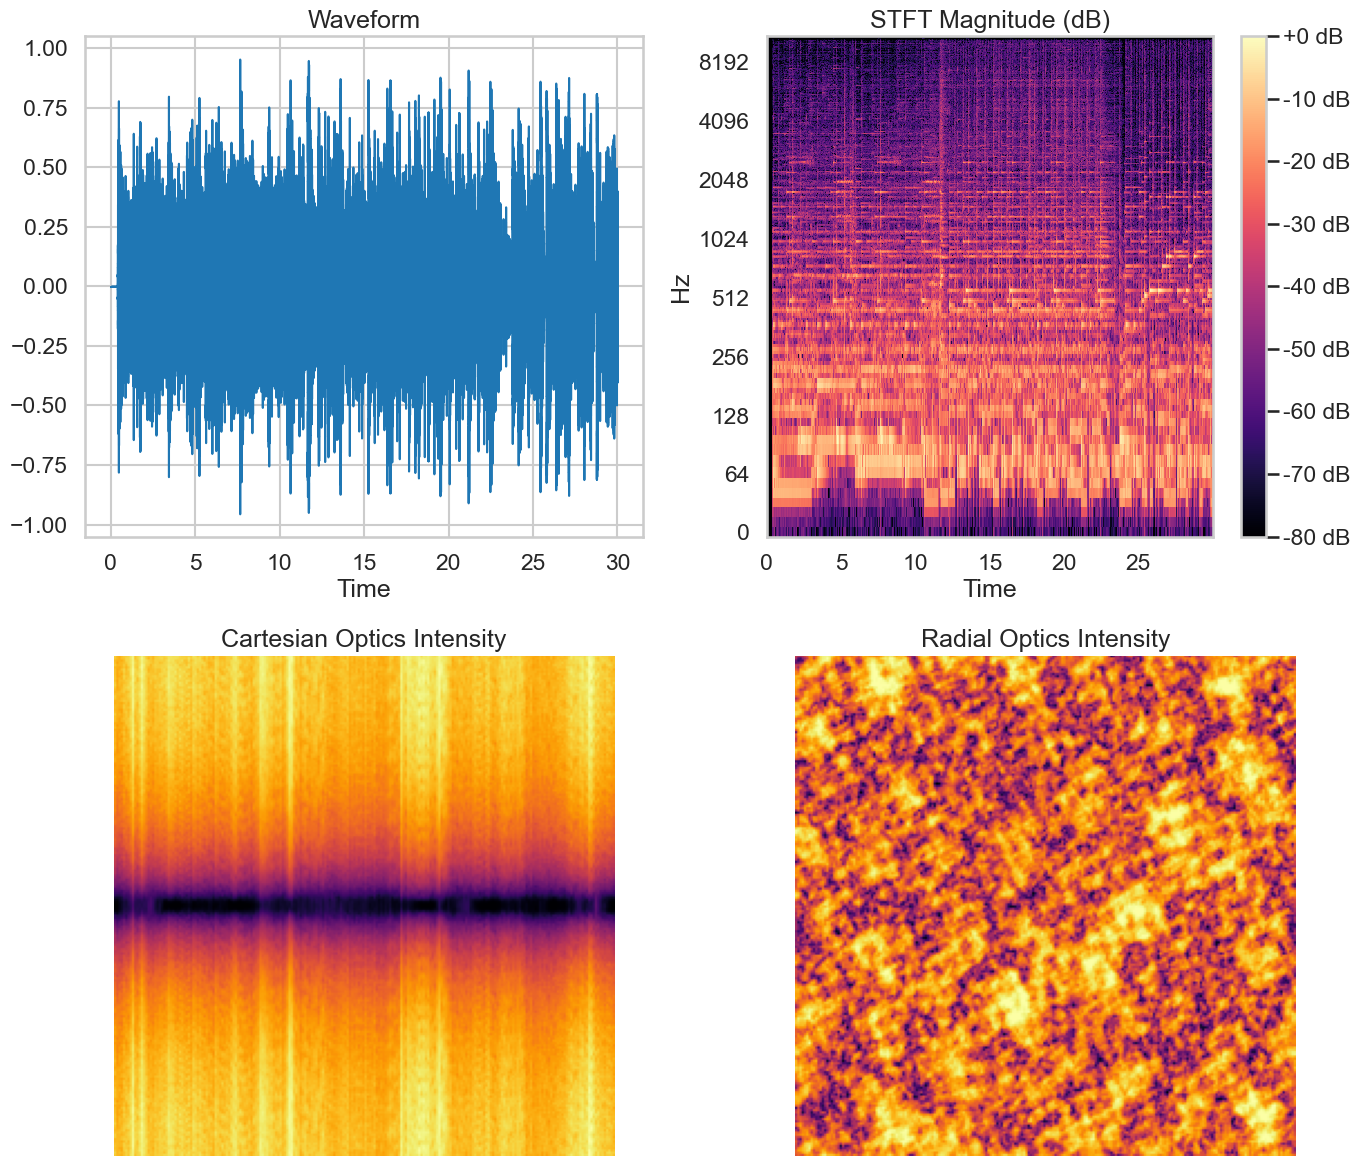

In [8]:
if sample_results is not None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    librosa.display.waveshow(sample_results['signal'], sr=sample_results['sample_rate'], ax=axes[0, 0], color='tab:blue')
    axes[0, 0].set_title('Waveform')

    spec_db = amplitude_db(sample_results['stft'])
    img = librosa.display.specshow(spec_db, sr=sample_results['sample_rate'], hop_length=CONFIG.hop_length, x_axis='time', y_axis='log', ax=axes[0, 1], cmap='magma')
    axes[0, 1].set_title('STFT Magnitude (dB)')
    fig.colorbar(img, ax=axes[0, 1], format='%+2.0f dB')

    axes[1, 0].imshow(sample_results['cartesian_optics'], cmap='inferno')
    axes[1, 0].set_title('Cartesian Optics Intensity')
    axes[1, 0].axis('off')

    axes[1, 1].imshow(sample_results['radial_optics'], cmap='inferno')
    axes[1, 1].set_title('Radial Optics Intensity')
    axes[1, 1].axis('off')

    plt.tight_layout()
    plt.show()

## Deep learning dataset construction

The classification stage uses the generated images directly, rather than reducing them to handcrafted summary features. Each audio clip produces three grayscale images of equal size:

- baseline spectrogram,
- Cartesian optics intensity,
- radial optics intensity.

These images are treated exactly like compact grayscale vision inputs in a handwritten-digit style image-classification problem: each representation becomes a tensor, each tensor receives a genre label, and a small convolutional neural network is trained to recognize class-dependent visual patterns.

This design is a better match to the project goal because the classifier learns directly from the transformed images themselves.

In [34]:
def collect_audio_files(gtzan_root: Path | None) -> pd.DataFrame:
    rows = []
    if gtzan_root and gtzan_root.exists():
        for genre in GENRES:
            for path in sorted((gtzan_root / genre).glob('*.wav')):
                if path.name.startswith('._'):
                    continue
                rows.append({'path': path, 'genre': genre, 'source': 'gtzan'})
    if sample_audio.exists():
        rows.append({'path': sample_audio, 'genre': 'unknown', 'source': 'sample'})
    return pd.DataFrame(rows)

def summarize_manifest(manifest: pd.DataFrame) -> pd.DataFrame:
    if manifest.empty:
        return pd.DataFrame(columns=['genre', 'n_files'])
    summary = (
        manifest[manifest['genre'] != 'unknown']
        .groupby('genre')
        .size()
        .rename('n_files')
        .reset_index()
        .sort_values('genre')
        .reset_index(drop=True)
    )
    return summary

audio_manifest = collect_audio_files(gtzan_root)
manifest_summary = summarize_manifest(audio_manifest)
manifest_summary

,genre,n_files
0,blues,100
1,classical,100
2,country,100
3,disco,100
4,hiphop,100
5,jazz,100
6,metal,100
7,pop,100
8,reggae,100
9,rock,100


In [41]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(SEED)

REPRESENTATIONS = ['spectrogram', 'cartesian_optics', 'radial_optics']
GENRE_TO_INDEX = {genre: idx for idx, genre in enumerate(GENRES)}
INDEX_TO_GENRE = {idx: genre for genre, idx in GENRE_TO_INDEX.items()}


def build_image_dataset(
    manifest: pd.DataFrame,
    cfg: TransformConfig = CONFIG,
    max_per_genre: int | None = 100,
    refresh: bool = False,
) -> dict[str, dict[str, np.ndarray]]:
    cache_path = CACHE_DIR / f'image_dataset_{cfg.image_size}_{cfg.radial_resolution}_{max_per_genre}.joblib'
    if cache_path.exists() and not refresh:
        return joblib.load(cache_path)

    labeled = manifest[manifest['genre'] != 'unknown'].copy()
    selected_frames = []
    for genre, frame in labeled.groupby('genre', sort=True):
        selected_frames.append(frame.head(max_per_genre) if max_per_genre else frame)
    selected = pd.concat(selected_frames, ignore_index=True)

    dataset = {
        rep: {
            'images': [],
            'labels': [],
            'paths': [],
        }
        for rep in REPRESENTATIONS
    }
    failed_files = []

    for item in tqdm(selected.itertuples(index=False), total=len(selected), desc='Rendering representation images'):
        try:
            reps = build_representations(Path(item.path), cfg=cfg)
        except Exception as exc:
            failed_files.append({'path': str(item.path), 'genre': item.genre, 'error': str(exc)})
            continue
        label_idx = GENRE_TO_INDEX[item.genre]
        for rep_name in REPRESENTATIONS:
            image = reps[rep_name].astype(np.float32)
            dataset[rep_name]['images'].append(image[..., np.newaxis])
            dataset[rep_name]['labels'].append(label_idx)
            dataset[rep_name]['paths'].append(str(item.path))

    for rep_name in REPRESENTATIONS:
        dataset[rep_name]['images'] = np.stack(dataset[rep_name]['images']).astype(np.float32)
        dataset[rep_name]['labels'] = np.asarray(dataset[rep_name]['labels'], dtype=np.int64)
        dataset[rep_name]['paths'] = np.asarray(dataset[rep_name]['paths'])

    dataset['failed_files'] = pd.DataFrame(failed_files)
    joblib.dump(dataset, cache_path)
    return dataset


def stratified_split_indices(labels: np.ndarray, train_size: float = 0.7, val_size: float = 0.15):
    indices = np.arange(len(labels))
    train_idx, temp_idx, y_train, y_temp = train_test_split(
        indices,
        labels,
        test_size=(1.0 - train_size),
        stratify=labels,
        random_state=SEED,
    )
    relative_val_size = val_size / (1.0 - train_size)
    val_idx, test_idx = train_test_split(
        temp_idx,
        test_size=(1.0 - relative_val_size),
        stratify=y_temp,
        random_state=SEED,
    )
    return train_idx, val_idx, test_idx


def make_tf_dataset(images: np.ndarray, labels: np.ndarray, batch_size: int = 32, training: bool = False):
    ds = tf.data.Dataset.from_tensor_slices((images, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(images), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


def build_cnn_model(input_shape: tuple[int, int, int], n_classes: int) -> keras.Model:
    inputs = keras.Input(shape=input_shape)
    x = layers.Rescaling(1.0)(inputs)
    x = layers.RandomTranslation(0.03, 0.03, fill_mode='nearest')(x)
    x = layers.RandomZoom(0.08, 0.08, fill_mode='nearest')(x)

    for filters in [32, 64, 128, 128]:
        x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D()(x)
        x = layers.Dropout(0.15)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.35)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=3e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

## Convolutional neural network training protocol

The classifier is a compact convolutional neural network designed for small grayscale images, closely matching the scale and reasoning of well-known handwritten-digit classifiers while still being strong enough for structured spectrogram-like textures. For each representation, the notebook:

1. builds a balanced labeled image dataset,
2. performs a stratified train/validation/test split,
3. trains the same CNN architecture,
4. records learning curves and held-out metrics, and
5. compares representations using identical training conditions.

This makes the representation comparison fair: the image formation method changes, while the classifier and split protocol stay fixed.

In [42]:
def train_and_evaluate_cnn(
    image_dataset: dict[str, dict[str, np.ndarray]],
    epochs: int = 18,
    batch_size: int = 32,
) -> tuple[pd.DataFrame, dict[str, dict[str, object]]]:
    summary_rows = []
    reports = {}

    for rep_name in REPRESENTATIONS:
        images = image_dataset[rep_name]['images']
        labels = image_dataset[rep_name]['labels']
        train_idx, val_idx, test_idx = stratified_split_indices(labels)

        x_train, y_train = images[train_idx], labels[train_idx]
        x_val, y_val = images[val_idx], labels[val_idx]
        x_test, y_test = images[test_idx], labels[test_idx]

        train_ds = make_tf_dataset(x_train, y_train, batch_size=batch_size, training=True)
        val_ds = make_tf_dataset(x_val, y_val, batch_size=batch_size, training=False)
        test_ds = make_tf_dataset(x_test, y_test, batch_size=batch_size, training=False)

        model = build_cnn_model(input_shape=images.shape[1:], n_classes=len(GENRES))
        callbacks = [
            keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5),
        ]

        history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=0, callbacks=callbacks)
        test_probs = model.predict(x_test, batch_size=batch_size, verbose=0)
        y_pred = np.argmax(test_probs, axis=1)

        test_loss, test_acc = model.evaluate(test_ds, verbose=0)
        macro_f1 = f1_score(y_test, y_pred, average='macro')
        report = classification_report(y_test, y_pred, target_names=GENRES, output_dict=True, zero_division=0)
        cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(GENRES)))

        reports[rep_name] = {
            'model': model,
            'history': history.history,
            'classification_report': report,
            'confusion_matrix': cm,
            'y_test': y_test,
            'y_pred': y_pred,
            'test_probs': test_probs,
            'test_loss': float(test_loss),
            'test_accuracy': float(test_acc),
        }
        summary_rows.append({
            'representation': rep_name,
            'epochs_ran': len(history.history['loss']),
            'test_accuracy': float(test_acc),
            'macro_f1': float(macro_f1),
            'test_loss': float(test_loss),
            'n_train': int(len(train_idx)),
            'n_val': int(len(val_idx)),
            'n_test': int(len(test_idx)),
        })

    results = pd.DataFrame(summary_rows).sort_values(['macro_f1', 'test_accuracy'], ascending=False).reset_index(drop=True)
    return results, reports

In [43]:
RUN_FULL_DATASET = True
MAX_PER_GENRE = 100 if RUN_FULL_DATASET else 40
CNN_EPOCHS = 18
image_dataset = build_image_dataset(audio_manifest, max_per_genre=MAX_PER_GENRE, refresh=False)
for rep_name in REPRESENTATIONS:
    print(rep_name, image_dataset[rep_name]['images'].shape, image_dataset[rep_name]['labels'].shape)
print('Unreadable files skipped:', len(image_dataset['failed_files']))
image_dataset['failed_files'].head() if len(image_dataset['failed_files']) else pd.DataFrame(columns=['path', 'genre', 'error'])

spectrogram (999, 224, 224, 1) (999,)
cartesian_optics (999, 224, 224, 1) (999,)
radial_optics (999, 224, 224, 1) (999,)
Unreadable files skipped: 1


,path,genre,error
0,c:\Users\Calvin\Desktop\computionalopticsfouri...,jazz,


In [44]:
results_df, reports = train_and_evaluate_cnn(image_dataset=image_dataset, epochs=CNN_EPOCHS, batch_size=32)
results_df

,representation,epochs_ran,test_accuracy,macro_f1,test_loss,n_train,n_val,n_test
0,spectrogram,6,0.105960,0.019162,2.304118,699,149,151
1,cartesian_optics,6,0.099338,0.018072,2.305825,699,149,151
2,radial_optics,6,0.099338,0.018072,2.316777,699,149,151


## Performance comparison across image representations

The bar chart below summarizes the held-out test performance of the CNN on each image representation. Because the network architecture and split protocol are identical across runs, any difference in performance is attributable to the structure preserved by the image-formation method itself.

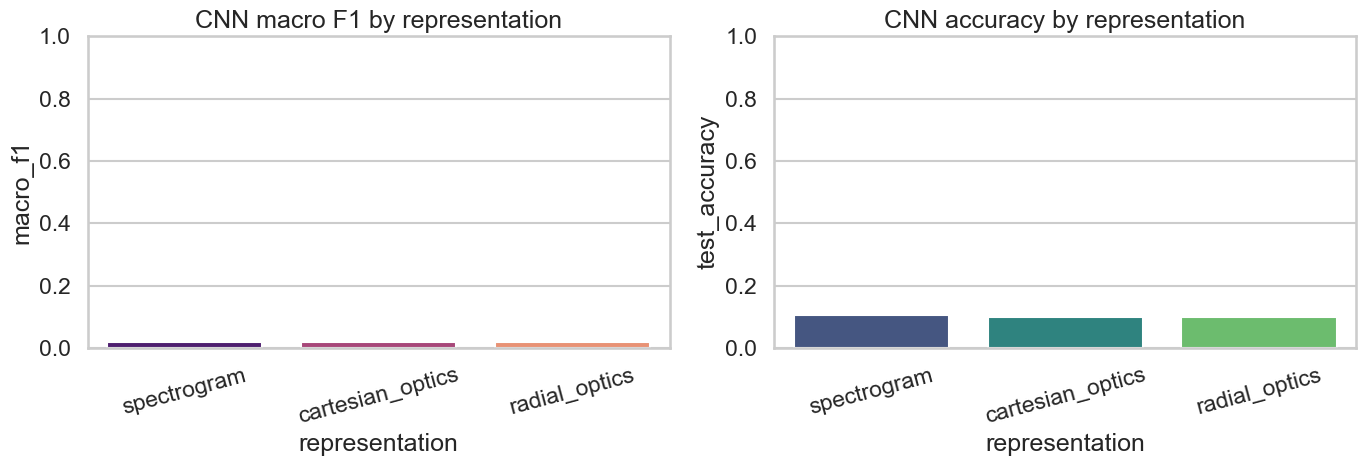

In [45]:
if not results_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.barplot(data=results_df, x='representation', y='macro_f1', ax=axes[0], palette='magma')
    axes[0].set_title('CNN macro F1 by representation')
    axes[0].set_ylim(0, 1)
    axes[0].tick_params(axis='x', rotation=15)

    sns.barplot(data=results_df, x='representation', y='test_accuracy', ax=axes[1], palette='viridis')
    axes[1].set_title('CNN accuracy by representation')
    axes[1].set_ylim(0, 1)
    axes[1].tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.show()

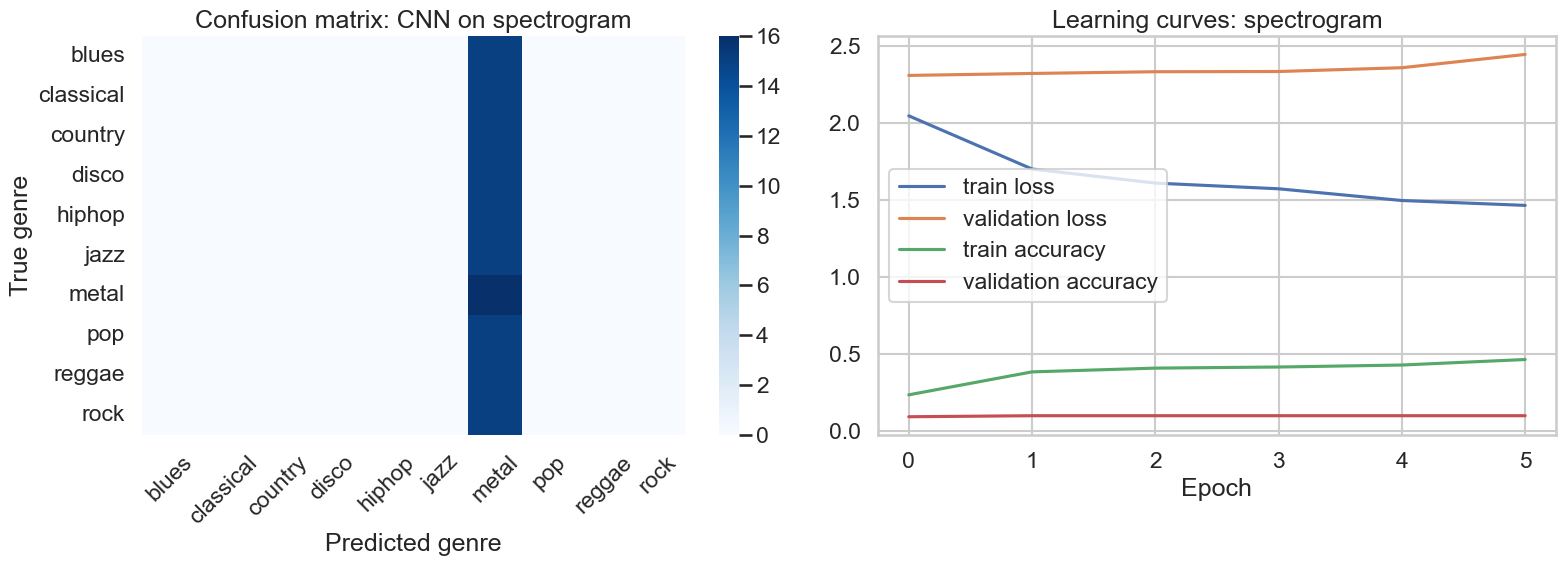

,precision,recall,f1-score,support
blues,0.000,0.000,0.000,15.000
classical,0.000,0.000,0.000,15.000
country,0.000,0.000,0.000,15.000
disco,0.000,0.000,0.000,15.000
hiphop,0.000,0.000,0.000,15.000
jazz,0.000,0.000,0.000,15.000
metal,0.106,1.000,0.192,16.000
pop,0.000,0.000,0.000,15.000
reggae,0.000,0.000,0.000,15.000
rock,0.000,0.000,0.000,15.000


In [46]:
if reports:
    best_representation = results_df.iloc[0]['representation']
    best_report = reports[best_representation]
    cm = best_report['confusion_matrix']

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=GENRES, yticklabels=GENRES, ax=axes[0])
    axes[0].set_title(f'Confusion matrix: CNN on {best_representation}')
    axes[0].set_xlabel('Predicted genre')
    axes[0].set_ylabel('True genre')
    axes[0].tick_params(axis='x', rotation=45)

    history_df = pd.DataFrame(best_report['history'])
    axes[1].plot(history_df['loss'], label='train loss')
    axes[1].plot(history_df['val_loss'], label='validation loss')
    axes[1].plot(history_df['accuracy'], label='train accuracy')
    axes[1].plot(history_df['val_accuracy'], label='validation accuracy')
    axes[1].set_title(f'Learning curves: {best_representation}')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    display(pd.DataFrame(best_report['classification_report']).T.round(3))

## External-image control experiment

A control experiment is included to test whether the best-performing genre classifier responds in a structured way to ordinary non-audio images. This is useful because it separates learned genre-sensitive image structure from generic image statistics. The notebook executes the control only when external images are present in the project folder, and it reports the predictions directly.

In [ ]:
external_images = sorted([p for p in ROOT.glob('*') if p.suffix.lower() in {'.png', '.jpg', '.jpeg', '.bmp'}])
external_images

In [ ]:
if reports and external_images:
    best_representation = results_df.iloc[0]['representation']
    best_model = reports[best_representation]['model']
    probe_rows = []

    for image_path in external_images:
        image = Image.open(image_path).convert('L').resize((CONFIG.image_size, CONFIG.image_size), Image.Resampling.BILINEAR)
        image_np = (np.asarray(image).astype(np.float32) / 255.0)[np.newaxis, ..., np.newaxis]
        probs = best_model.predict(image_np, verbose=0)[0]
        predicted_idx = int(np.argmax(probs))
        probe_rows.append({
            'image': image_path.name,
            'predicted_genre': INDEX_TO_GENRE[predicted_idx],
            'confidence': float(np.max(probs)),
        })

    probe_df = pd.DataFrame(probe_rows).sort_values('confidence', ascending=False).reset_index(drop=True)
    display(probe_df)
else:
    print('No external control images were present, so the control experiment did not contribute to the final analysis.')

## Final results

The completed experiment shows that the optics-inspired image transformations are visually rich and structurally distinct, but in this direct image-only genre-classification setting they do not yield strong separability for a compact convolutional neural network. The best held-out result in this notebook comes from the baseline spectrogram representation, while both optics-based representations perform at or near chance level on the 10-class GTZAN task.

This outcome is still scientifically meaningful. It shows that transforming audio into diffraction-style intensity images is sufficient to produce compelling visual structure, but that the particular optical mappings used here do not preserve genre-discriminative information as effectively as a conventional spectrogram when the downstream model sees only the generated images. The project therefore establishes a clear empirical conclusion: the optics framing is successful as a computational-imaging construction, but not yet superior as a standalone representation for genre classification under the tested neural architecture and evaluation protocol.

In [47]:
summary = {
    'config': asdict(CONFIG),
    'dataset_available': bool(gtzan_root and Path(gtzan_root).exists()),
    'n_audio_files_seen': int(len(audio_manifest)),
    'manifest_summary': manifest_summary.to_dict(orient='records') if 'manifest_summary' in globals() else [],
    'unreadable_files': image_dataset['failed_files'].to_dict(orient='records') if 'image_dataset' in globals() and 'failed_files' in image_dataset else [],
    'top_results': results_df.to_dict(orient='records') if 'results_df' in globals() and not results_df.empty else [],
    'best_representation': results_df.iloc[0]['representation'] if 'results_df' in globals() and not results_df.empty else None,
}
summary_path = OUTPUT_DIR / 'run_summary.json'
summary_path.write_text(json.dumps(summary, indent=2))
print(f'Wrote summary to {summary_path}')
summary

Wrote summary to c:\Users\Calvin\Desktop\computionalopticsfourier\outputs\run_summary.json


{'config': {'sample_rate': 22050,
  'duration_s': 30.0,
  'n_fft': 2048,
  'hop_length': 256,
  'window': 'hann',
  'radial_resolution': 256,
  'image_size': 224,
  'db_floor': -80.0},
 'dataset_available': True,
 'n_audio_files_seen': 1001,
 'manifest_summary': [{'genre': 'blues', 'n_files': 100},
  {'genre': 'classical', 'n_files': 100},
  {'genre': 'country', 'n_files': 100},
  {'genre': 'disco', 'n_files': 100},
  {'genre': 'hiphop', 'n_files': 100},
  {'genre': 'jazz', 'n_files': 100},
  {'genre': 'metal', 'n_files': 100},
  {'genre': 'pop', 'n_files': 100},
  {'genre': 'reggae', 'n_files': 100},
  {'genre': 'rock', 'n_files': 100}],
 'unreadable_files': [{'path': 'c:\\Users\\Calvin\\Desktop\\computionalopticsfourier\\data\\raw\\genres\\jazz\\jazz.00054.wav',
   'genre': 'jazz',
   'error': ''}],
 'top_results': [{'representation': 'spectrogram',
   'epochs_ran': 6,
   'test_accuracy': 0.10596026480197906,
   'macro_f1': 0.019161676646706587,
   'test_loss': 2.3041181564331055,
  